<a href="https://colab.research.google.com/github/dusandraq/Machine-Learning-Homework/blob/main/Ass4breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample data shape: (569, 30)

Sample target shape: (569,)

Training data shape: (426, 30)

Training target shape: (426,)

Model Score: 0.951048951048951

Confusion Matrix: [[44  6]
 [ 1 92]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



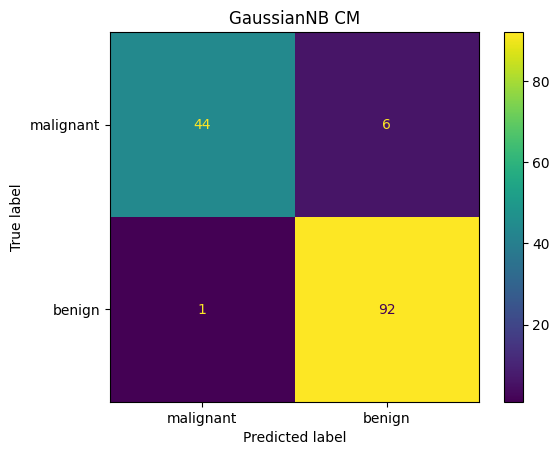

Scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Scores Mean Accuracy: 0.9384711779448622
Scores Standard Deviation: 0.02750305414538902

Median: 0.9473684210526315

Minimum: 0.8947368421052632

Maximum: 0.9649122807017544

IQR: 0.07017543859649122

Multiple Models with 10 folds

GaussianNB: mean accuracy = 0.94
standard deviation = 0.03

LinearRegression: mean accuracy = 0.74
standard deviation = 0.04

KNeighborsClassifier: mean accuracy = 0.93
standard deviation = 0.02

LogisticRegression: mean accuracy = 0.95
standard deviation = 0.03

SVC: mean accuracy = 0.92
standard deviation = 0.04


In [1]:
#No internet when working so I wrote in pycharm and copied to colab.

import matplotlib.pyplot as plt # for graphing
import numpy as np # may need?
import seaborn as sns # used for visualization
from sklearn.datasets import load_breast_cancer #Data set to load
from sklearn.model_selection import train_test_split, KFold, cross_val_score #For training data
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay #data metrics
from sklearn.svm import SVC #used to classify data
from sklearn.linear_model import LinearRegression, LogisticRegression  # continous relationships globally
from sklearn.neighbors import KNeighborsClassifier # local clusters relationships
from sklearn.naive_bayes import GaussianNB # probability distributions


#step 1
breast_cancer = load_breast_cancer() #load data set

#step 2
print(f"Sample data shape: {breast_cancer.data.shape}\n") #Sample and Target sizes
print(f"Sample target shape: {breast_cancer.target.shape}\n")

#step 3
X_train, X_test, y_train, y_test = train_test_split(breast_cancer.data, breast_cancer.target, random_state=11) #Splitting data for training and testing

#step 4
print(f"Training data shape: {X_train.shape}\n")
print(f"Training target shape: {y_train.shape}\n") #showing set sizes

#step 5
bc = GaussianNB()
bc.fit(X=X_train, y=y_train) # Train the model

#step 6
predicted = bc.predict(X=X_test) # predicting step

#step 7
print(f"Model Score: {bc.score(X_test, y_test)}\n") # Estimator method score

#step 8 & 9
confusion_matrix = confusion_matrix(y_true = y_test, y_pred = predicted) #confusion matrix
print(f"Confusion Matrix: {confusion_matrix}\n")
print("Classification Report:") #print out classification report
print(classification_report(y_true = y_test, y_pred = predicted, target_names=breast_cancer.target_names))

#step 10
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=breast_cancer.target_names)
display.plot() #use imported CMD to display CM, I liked the style so I did not change parameters in plot.
plt.title("GaussianNB CM")
plt.show()

#step 11
kfold = KFold(n_splits=10, shuffle=True, random_state=11) #folds for cross validation

#step 12
scores = cross_val_score(estimator=bc, X=breast_cancer.data, y=breast_cancer.target, cv=kfold)
print(f"Scores: {scores}") #using kfold with cross validation for Gaussian model.
print(f"Scores Mean Accuracy: {scores.mean()}")
print(f"Scores Standard Deviation: {scores.std()}\n")

#step 13
estimators = { # dictionary to hold key:value pairs of models
    'GaussianNB': bc,
    'LinearRegression': LinearRegression(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', max_iter=10000),
    'SVC': SVC(gamma = 'scale'),
}

median = np.median(scores)
min = np.min(scores)      #Just messing with numpy things
max = np.max(scores)
iqr = max - min
print(f"Median: {median}\n")
print(f"Minimum: {min}\n")
print(f"Maximum: {max}\n")
print(f"IQR: {iqr}\n")

#step 14
print("Multiple Models with 10 folds")
for name, model in estimators.items():
    cv = cross_val_score(estimator=model, X=breast_cancer.data, y=breast_cancer.target, cv=kfold)
    print(f"\n{name:}: mean accuracy = {cv.mean():.2f}\n"
          f"standard deviation = {cv.std():.2f}"
          )


